# IPO Long-Run Underperformance — a quantitative teardown 🔬
### NW-t cohort inference on 45 overlapping vintages · HAC spread & alpha tests on the live ETF tape vs three benchmarks · the style-absorption two-factor regression · borrow-and-cost sweeps on the short · a seed-averaged power analysis

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Small-growth beta?: Confirmed](https://img.shields.io/badge/Small--growth_beta%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Ritter's 3-5 year IPO drift is one of the most-cited results in finance — the job here is to separate the **published record** (real, but style-fragile) from what an **investable tape** can actually certify (nothing, at this sample size), and to say which villain — the IPO event or the small-growth style — the data indicts.

> ⚠️ **Data note.** Track A = Ritter Table 19 (updated 2026-02-16), hardcoded from the source PDF (cached in `_cache/`): *published, pre-aggregated* data — by desk law it carries the literature story, never the REAL stamp. Track B = yfinance total-return tape of IPO/SPY/IWM/IWO + ^IRX, Nov 2013 → Jun 2026 (152 months), cache-first. Neither track is survivor-biased (Ritter follows IPOs to delisting; the ETF's NAV nets its losers), but the live window covers **2013+ only** — the named regime caveat. Numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `65b022ff4f0e`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ipo_long_run_underperformance import data, strategy as st

COHORTS = data.ritter_cohorts()                    # Track A: always offline (hardcoded)
HAVE_REAL = data.have_real()                       # Track B: cache-first
PANEL = data.monthly_panel(data.load_tape()) if HAVE_REAL else None
print("Ritter cohorts:", len(COHORTS), "| live ETF cache present:", HAVE_REAL,
      "| months:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': '65b022ff4f0e', 'n_cohorts': 45, 'n_ipos': 9253, 'first_day_pct': 18.9, 'raw': (22.5, 3.2, 19.13, 22.2), 'mkt': (-14.2, -2.26, -20.51, 71.1), 'style': (-8.46, -1.52, -8.87, 66.7), 'mkt_extrunc': (-12.03, -2.18), 'style_extrunc': (-6.6, -1.37), 'n_months': 152, 'years': 12.7, 'start': '2013-11-30', 'end': '2026-06-30', 'growth': {'IPO': (3.1, 9.34), 'SPY': (5.27, 14.02), 'IWM': (3.25, 9.74), 'IWO': (3.37, 10.07)}, 'rel_peak': 1.45, 'rel_peak_date': '2021-01', 'rel_end': 0.59, 'rel_dd': -67.5, 'share_beat': 50.0, 'vs_spy': (-16.36, -1.95, -0.31, -46.71, -5.46, -0.99, 1.293), 'vs_iwm': (8.39, 1.01, 0.17, 8.86, 1.07, 0.18, 0.994), 'vs_iwo': (4.79, 0.58, 0.12, 0.23, 0.03, 0.01, 1.055), 'two_factor': (-4.66, -0.56, -0.12, 1.091, 0.999), 'overlay': [(5.0, 1.0, 16.36, 0.31, 7.63, 0.92, 0.15, -57.4), (10.0, 1.0, 16.36, 0.31, 7.23, 0.87, 0.14, -57.5), (5.0, 2.0, 16.36, 0.31, -0.7, -0.08, -0.01, -59.5)], 'syn': [(0.0, 6.31, 0.21, 5.0), (-50.0, -43.69, -1.83, 45.0), (-100.0, -93.69, -3.88, 95.0)]}


Ritter cohorts: 45 | live ETF cache present: True | months: 152


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Published record: market-adjusted **-14.20%/3yr**, **NW t = -2.26** across 45 cohorts — but style-adjusted only **-8.46%** at **t = -1.52**, and the live investable tape shows vs-SPY alpha **t = -0.99**, style-matched alpha ≈ 0. Literature real; tape can't certify. |
| **Tradability** | `MIRAGE` | Short-IPO/long-SPY nets **+0.92%/yr** (t = +0.15) at 5 bps + 1% borrow, **-0.08%/yr** at 2% borrow, max drawdown **-57.4%**. |
| **Small-growth beta?** | `CONFIRMED` | Ritter: −14.2% → −8.5% (t −2.26 → −1.52) after style-matching; live: alpha -5.46%/yr vs SPY → **+0.03%/yr vs IWO**, two-factor alpha **t = -0.12** with style loading **0.999**. |

> 💡 In plain words: history shows the drift, but everything a trader could actually hold says "you bought expensive small-growth" — and there's no alpha left once you name it that.

## 1 · The claim, steelmanned

Let $BHAR^{3y}_c$ be the equal-weighted average 3-year buy-and-hold abnormal return of IPO cohort $c$ (measured from the **first closing price** — the pop excluded by construction), against benchmark $b \in \{\text{market}, \text{style match}\}$.

- **H₁ (the drift exists).** $\mathbb{E}[BHAR^{3y}] < 0$, significant under serial-correlation-robust inference (consecutive cohorts overlap by 2 years).
- **H₂ (it lives on an investable tape).** A basket of recent IPOs (the Renaissance IPO ETF, which holds listings for ~2-3 years) shows negative HAC alpha vs its benchmark, 2013-2026.
- **H₃ (it is IPO-ness, not style).** The drag survives style adjustment — matched seasoned small-growth firms (Track A) or IWO / a small-growth factor (Track B).

We find **H₁ supported vs the market** (NW t = −2.26) **but not style-adjusted** (t = −1.52), **H₂ rejected at this sample size** (t = −0.99), **H₃ rejected** — the style absorbs essentially the whole drag. Hence WEAK / MIRAGE / CONFIRMED.

## 2 · So what? — the honesty problems this design must survive

1. **Overlapping windows.** Annual cohorts holding 3-year returns are serially correlated by construction → Newey-West with lag 3 across cohorts, not naive iid t.
2. **Published aggregates ≠ our tape.** Table 19 is pre-averaged by Ritter from CRSP — we can re-frame it, but the desk's REAL stamp requires *our own* investable tape to clear t ≥ 2 (it is exactly how a literature darling gets an honest grade).
3. **Benchmark sensitivity (Fama 1998).** Long-horizon BHARs flip sign with the benchmark — so every result is shown raw, market-adjusted and style-adjusted.
4. **Truncation.** The 2023-24 cohorts have < 3 full years of returns — results are shown with and without them.
5. **Costs where they belong.** The tradable expression is a *short* — it pays borrow monthly and one-way costs × NAV on the re-hedge, both legs counted; the spread is self-financing so the race is excess-vs-excess by construction; there is **no signal lag to apply** (always-on, calendar-known rule — documented, not forgotten).

## 3 · How we'd know — the protocol

- **Track A.** Ritter Table 19: 45 cohort years, 9,253 IPOs. One EW mean 3-yr BHAR per cohort; NW t (lag 3) on raw / market-adj / style-adj; N-weighted means and share-negative reported; ex-truncation robustness.
- **Track B.** Monthly total returns 2013-11-30 → 2026-06-30 (152 months). (i) self-financing spread IPO−bench, HAC t (lag 6); (ii) CAPM-style alpha of IPO excess on bench excess (^IRX risk-free), HAC intercept t; benches = SPY, IWM, IWO. (iii) two-factor: $r_{IPO}-r_f = \alpha + \beta_m (r_{SPY}-r_f) + \beta_s (r_{IWO}-r_{SPY}) + \epsilon$ — the live analogue of Ritter's style match.
- **Tradability.** Short IPO / long SPY, borrow ∈ {1%, 2%}/yr charged monthly, one-way costs ∈ {5, 10} bps × re-hedge turnover, max drawdown reported.
- **Control.** Synthetic beta-1.25 worlds with planted alpha ∈ {0, −50, −100} bps/mo, **20 seeds each** (desk law): null must reject ≈ 5%, drags must be recovered — and the power at Ritter-size is quantified, not assumed.

## 4 · The teardown

### 4a · Track A — the cohort record under NW inference

45 vintages, three benchmarks. The question: is the mean cohort BHAR below zero once the overlap is respected?

raw          mean  +22.50%/3yr  NW t = +3.20  (N-wtd +19.13%, 22.2% negative)
market-adj   mean  -14.20%/3yr  NW t = -2.26  (N-wtd -20.51%, 71.1% negative)
style-adj    mean   -8.46%/3yr  NW t = -1.52  (N-wtd -8.87%, 66.7% negative)
ex-truncated market-adj: mean -12.03%  NW t = -2.18  (n=43)
ex-truncated style-adj: mean -6.60%  NW t = -1.37  (n=43)


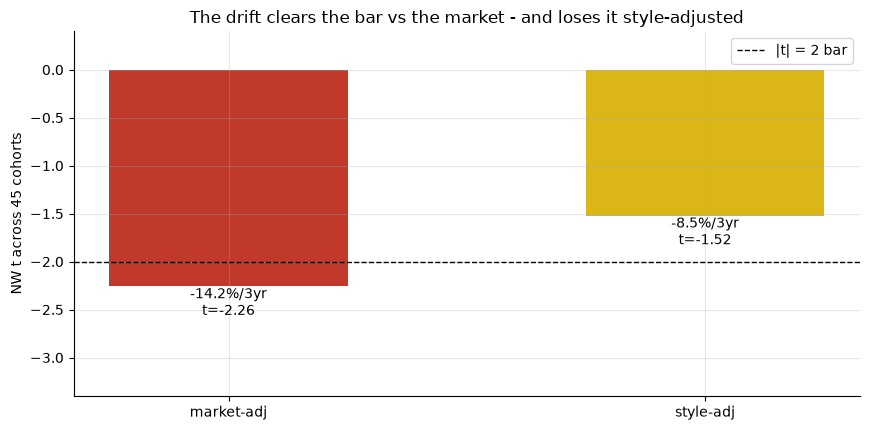

In [2]:
rows = []
for col, label in (('bhr3_raw','raw'), ('bhr3_mkt_adj','market-adj'), ('bhr3_style_adj','style-adj')):
    s = st.cohort_stats(COHORTS, col, lags=3)
    rows.append((label, s['mean_pct'], s['t_nw'], s['weighted_mean_pct'], s['share_negative']*100))
    print(f"{label:12s} mean {s['mean_pct']:+7.2f}%/3yr  NW t = {s['t_nw']:+.2f}  "
          f"(N-wtd {s['weighted_mean_pct']:+.2f}%, {s['share_negative']*100:.1f}% negative)")
co2 = data.ritter_cohorts(drop_truncated=True)
for col, label in (('bhr3_mkt_adj','market-adj'), ('bhr3_style_adj','style-adj')):
    s = st.cohort_stats(co2, col, lags=3)
    print(f'ex-truncated {label}: mean {s["mean_pct"]:+.2f}%  NW t = {s["t_nw"]:+.2f}  (n=43)')
fig, ax = plt.subplots(figsize=(8.8, 4.4))
labels = [r[0] for r in rows[1:]]; ts = [r[2] for r in rows[1:]]
ax.bar(labels, ts, color=[RED, AMBER], width=.5)
ax.axhline(-2, ls='--', c='k', lw=1, label='|t| = 2 bar')
for i, r in enumerate(rows[1:]):
    ax.annotate(f'{r[1]:+.1f}%/3yr\nt={r[2]:+.2f}', (i, r[2]), ha='center', va='top')
ax.set_ylabel('NW t across 45 cohorts'); ax.set_ylim(-3.4, 0.4)
ax.set_title('The drift clears the bar vs the market - and loses it style-adjusted')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: vs the market the 45-year drift is solid (**-14.2%/3yr, NW t = -2.26**, 71% of vintages negative, robust ex-truncation at t = -2.18). Style-matched it shrinks to **-8.5%** at **t = -1.52** — *below* the bar. Ritter's own tables carry Brav & Gompers' rebuttal inside them. And this is published, pre-aggregated data — the stamp is decided on Track B.

### 4b · Track B — the investable tape

The relative wealth line (IPO/SPY) tells the story of *why* the legend survived: two manias and two collapses.

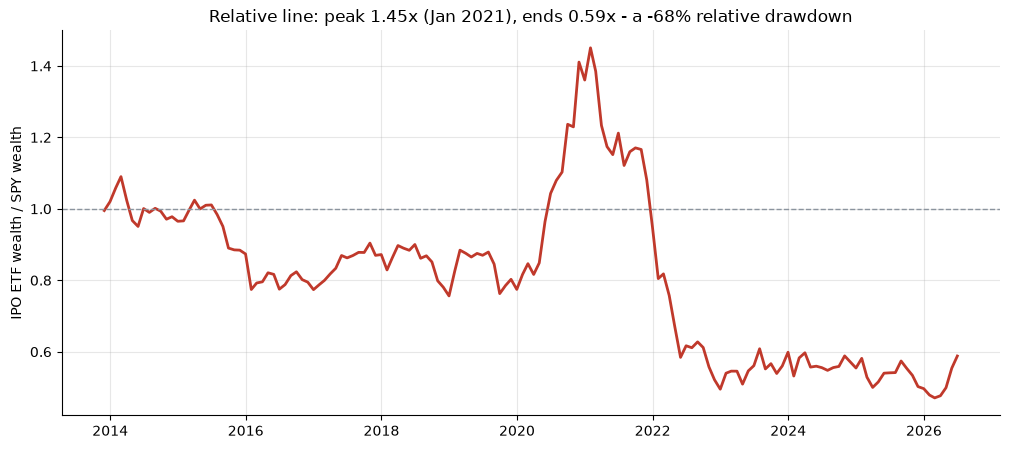

peak 1.45x (2021-01-31)  end 0.59x  share of months IPO>SPY: 50.0%


In [3]:
if HAVE_REAL:
    rel = (np.exp(np.log1p(PANEL['IPO']).cumsum()) / np.exp(np.log1p(PANEL['SPY']).cumsum()))
    fig, ax = plt.subplots(figsize=(10.2, 4.6))
    ax.plot(rel.index, rel.values, c=RED, lw=2)
    ax.axhline(1.0, c=GREY, ls='--', lw=1)
    ax.set_ylabel('IPO ETF wealth / SPY wealth'); ax.set_title(
        f'Relative line: peak {R["rel_peak"]:.2f}x (Jan 2021), ends {R["rel_end"]:.2f}x '
        f'- a {R["rel_dd"]:.0f}% relative drawdown')
    plt.tight_layout(); plt.show()
    print(f'peak {rel.max():.2f}x ({rel.idxmax().date()})  end {rel.iloc[-1]:.2f}x  '
          f'share of months IPO>SPY: {(PANEL["IPO"]>PANEL["SPY"]).mean()*100:.1f}%')
else:
    print('(cache missing)', 'peak', R['rel_peak'], 'end', R['rel_end'], 'dd%', R['rel_dd'])

Now the inference: HAC (NW, lag 6) spreads and alphas against each benchmark, plus the two-factor style regression.

bench   spread bps/mo      t  alpha bps/mo      t   beta
SPY            -16.36  -0.31        -46.71  -0.99  1.293
IWM             +8.39  +0.17         +8.86  +0.18  0.994
IWO             +4.79  +0.12         +0.23  +0.01  1.055
2-factor alpha -4.66 bps/mo  t = -0.12  beta_mkt = 1.091  beta_style = 0.999


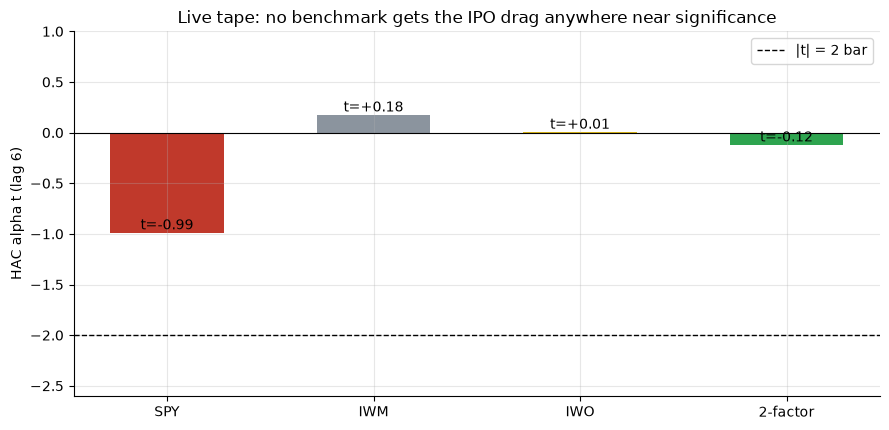

In [4]:
if HAVE_REAL:
    print(f"{'bench':6s} {'spread bps/mo':>14s} {'t':>6s} {'alpha bps/mo':>13s} {'t':>6s} {'beta':>6s}")
    tvals = {}
    for b in ('SPY','IWM','IWO'):
        sp = st.spread_stats(PANEL, b, lags=6); al = st.alpha_stats(PANEL, b, lags=6)
        tvals[b] = al['alpha_t']
        print(f"{b:6s} {sp['mean_bps']:>+14.2f} {sp['t_nw']:>+6.2f} {al['alpha_bps']:>+13.2f} "
              f"{al['alpha_t']:>+6.2f} {al['beta']:>6.3f}")
    tf = st.two_factor_alpha(PANEL, lags=6)
    tvals['2-factor'] = tf['alpha_t']
    print(f"2-factor alpha {tf['alpha_bps']:+.2f} bps/mo  t = {tf['alpha_t']:+.2f}  "
          f"beta_mkt = {tf['beta_mkt']:.3f}  beta_style = {tf['beta_style']:.3f}")
else:
    tvals = {'SPY': R['vs_spy'][5], 'IWM': R['vs_iwm'][5], 'IWO': R['vs_iwo'][5], '2-factor': R['two_factor'][2]}
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ks = list(tvals)
ax.bar(ks, [tvals[k] for k in ks], color=[RED, GREY, AMBER, GREEN], width=.55)
ax.axhline(-2, ls='--', c='k', lw=1, label='|t| = 2 bar'); ax.axhline(0, c='k', lw=.8)
for i, k in enumerate(ks): ax.annotate(f't={tvals[k]:+.2f}', (i, tvals[k]), ha='center', va='bottom')
ax.set_ylabel('HAC alpha t (lag 6)'); ax.set_ylim(-2.6, 1.0)
ax.set_title('Live tape: no benchmark gets the IPO drag anywhere near significance')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: vs SPY the ETF *looks* dragged (alpha **-46.7 bps/mo ≈ -5.5%/yr**) but at **t = -0.99** it's noise — and the beta is **1.29**, i.e. a leveraged market basket. Re-benchmark to what it actually *is* (small growth): alpha vs IWO = **+0.23 bps/mo** (t = +0.01); two-factor alpha **-4.66 bps/mo** (t = -0.12) with a style loading of **0.999**. The live IPO basket is small-growth beta wearing a ticker-confetti costume.

### 4c · Tradability — shorting the drift, net of frictions

Always-on short-IPO / long-SPY, monthly re-hedge; borrow charged monthly on the short leg, one-way costs × NAV on the turnover (both legs).

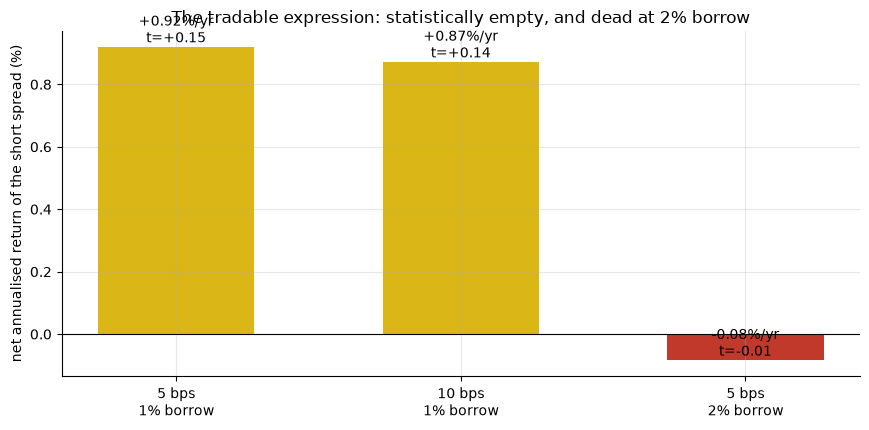

cost=5bps borrow=1%: net +7.63 bps/mo (+0.92%/yr, t=+0.15), maxDD -57.4%
cost=10bps borrow=1%: net +7.23 bps/mo (+0.87%/yr, t=+0.14), maxDD -57.5%
cost=5bps borrow=2%: net -0.70 bps/mo (-0.08%/yr, t=-0.01), maxDD -59.5%


In [5]:
if HAVE_REAL:
    rows = [st.short_overlay_stats(PANEL, 'SPY', cost_bps=cb, borrow_ann_pct=br, lags=6)
            for cb, br in ((5.0, 1.0), (10.0, 1.0), (5.0, 2.0))]
    rows = [(r['cost_bps'], r['borrow_ann_pct'], r['net_bps'], r['net_ann_pct'], r['net_t'],
             r['worst_drawdown_pct']) for r in rows]
else:
    rows = [(o[0], o[1], o[4], o[5], o[6], o[7]) for o in R['overlay']]
labels = [f'{int(c)} bps\n{int(b)}% borrow' for c, b, *_ in rows]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(labels, [r[3] for r in rows], color=[AMBER, AMBER, RED], width=.55)
ax.axhline(0, c='k', lw=.8)
for i, r in enumerate(rows):
    ax.annotate(f'{r[3]:+.2f}%/yr\nt={r[4]:+.2f}', (i, r[3]), ha='center', va='bottom')
ax.set_ylabel('net annualised return of the short spread (%)')
ax.set_title('The tradable expression: statistically empty, and dead at 2% borrow')
plt.tight_layout(); plt.show()
for c, b, nb, na, nt, dd in rows:
    print(f'cost={c:.0f}bps borrow={b:.0f}%: net {nb:+.2f} bps/mo ({na:+.2f}%/yr, t={nt:+.2f}), maxDD {dd:.1f}%')

> 💡 In plain words: the best case keeps **+0.92%/yr** at **t = +0.15** — indistinguishable from zero — after having been **-57%** underwater when IPOs doubled into Feb 2021. At 2%/yr borrow the net is **-0.08%/yr**. No capacity, no accessibility issue even needs discussing: there is no edge to deploy. **MIRAGE.**

### 4d · Faithful-engine & power control — we know the truth here

Synthetic beta-1.25 worlds with a planted monthly alpha; the HAC-alpha detector runs on **20 seeds per edge** (desk law — no single-seed baselines). The null must reject at ≈ 5%; planted drags must be recovered; and the power at a Ritter-sized drag tells us how much the live t = −0.99 can and cannot say.

planted    +0.0 bps/mo: measured   +6.31 bps/mo  mean t = +0.21  reject rate = 5%
planted   -50.0 bps/mo: measured  -43.69 bps/mo  mean t = -1.83  reject rate = 45%
planted  -100.0 bps/mo: measured  -93.69 bps/mo  mean t = -3.88  reject rate = 95%


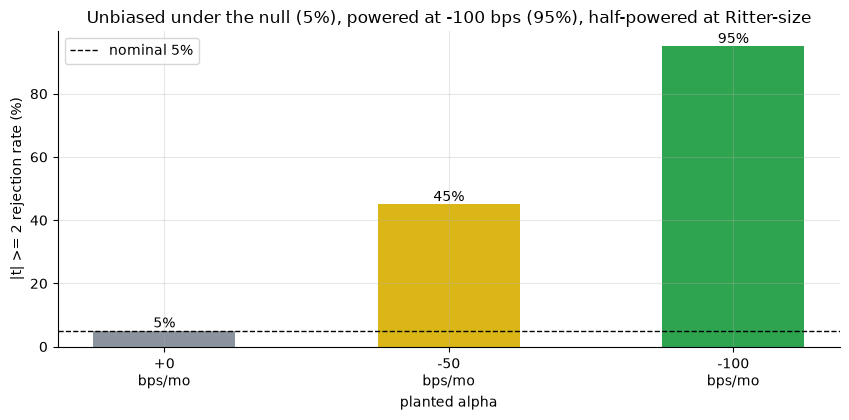

In [6]:
res = [st.synthetic_control(e, n_seeds=20, lags=6) for e in (0.0, -0.005, -0.010)]
for r in res:
    print(f"planted {r['edge_bps']:+7.1f} bps/mo: measured {r['mean_alpha_bps']:+7.2f} bps/mo  "
          f"mean t = {r['mean_t']:+.2f}  reject rate = {r['reject_rate']*100:.0f}%")
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labels = [f"{r['edge_bps']:+.0f}\nbps/mo" for r in res]
ax.bar(labels, [r['reject_rate']*100 for r in res], color=[GREY, AMBER, GREEN], width=.5)
ax.axhline(5, ls='--', c='k', lw=1, label='nominal 5%')
for i, r in enumerate(res):
    ax.annotate(f"{r['reject_rate']*100:.0f}%", (i, r['reject_rate']*100), ha='center', va='bottom')
ax.set_xlabel('planted alpha'); ax.set_ylabel('|t| >= 2 rejection rate (%)')
ax.set_title('Unbiased under the null (5%), powered at -100 bps (95%), half-powered at Ritter-size')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the machinery is honest — a zero-alpha world fires exactly **5%** of the time (nominal), a −100 bps/mo drag is caught **95%** of the time. A Ritter-sized −50 bps/mo drag is caught only **45%** of the time in 152 months, so the live tape *could* be missing a modest true drag — which is exactly why the Signal reads **WEAK** (open verdict) and not **NONE**. What the tape *does* nail is the third axis: whatever drag exists is absorbed by the style factor. *(Machinery/power proof only — never cited in support of a stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — the published record is real vs the market (**-14.20%/3yr, NW t = -2.26**, 71% of 45 cohorts negative) but fails style-adjusted (**t = -1.52**), and the live investable tape cannot certify it (alpha t = -0.99 vs SPY, ≈ 0 style-matched; 45% power at Ritter-size, stated). Literature says real; this tape alone can't — WEAK by the inference bar. No survivorship on either track; live window is 2013+ only (named).
- **Tradability `MIRAGE`** — net short spread **+0.92%/yr** at t = +0.15 (5 bps + 1% borrow), **-0.08%/yr** at 2% borrow, max drawdown **-57%**. Nothing survives.
- **Small-growth beta? `CONFIRMED`** — Ritter's own style match cuts the drag to insignificance, and the live two-factor alpha is **-4.66 bps/mo** (t = -0.12) with a **0.999** loading on the small-growth spread. Brav & Gompers (1997) win the third axis.

## 6 · Going further

- **Fama's warning generalises.** Long-horizon BHAR anomalies live and die by the benchmark (Fama 1998); this study is a live demonstration — the same tape reads −5.5%/yr or 0.0%/yr depending on the deflator.
- **The vintages carry the volume story.** The catastrophic cohorts (1999-2000, 2020-21) are exactly the high-volume manias — the timing signal explored in [265-ipo-volume](../../265-ipo-volume/); and the pop that never reached you is [219-ipo-pop](../../219-ipo-pop/).
- **What would change the stamp.** A point-in-time, style-adjusted IPO panel (CRSP-grade, delisting returns included) showing a post-2000 alpha with t ≥ 2 — or another decade of ETF tape. The desk re-runs on cache refresh.

*The reproducible core is offline and deterministic; Track A is hardcoded from the cached source PDF, Track B is cache-first yfinance. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*